## Data Import for Recommendation System

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load datasets
df_unified_resume_mapped_aligned = pd.read_csv("df_unified_resume_mapped_aligned.csv")
df_occ = pd.read_csv("Unified_Occupation_Dataset.csv")
df_occ_name_desc = pd.read_csv("Occupation Data.csv")

In [ ]:
df_unified_resume_mapped_aligned.head()

,Occupation,Resume_Text,Mapped_ONET_Code,Mapped_ONET_Title,Similarity_Score,Aligned_Text
0,Python Developer,preference python developer python tensorflow ...,15-1252.00,Software Developers,0.642890,c c++ education and training engineering and t...
1,Operations Manager,preference experienced operations manager expe...,13-1199.00,"Business Operations Specialists, All Other",0.703321,administration and management c computers and ...
2,DevOps Engineer,provided provided provided preference provided...,15-1299.08,Computer Systems Engineers/Architects,0.680222,amazon elastic compute cloud ec2 c c++ design ...
3,Python Developer,preference atos syntel industry services size ...,15-1252.00,Software Developers,0.642890,design django education and training engineeri...
4,Python Developer,maharashtra preference cybage software pvt. lt...,15-1252.00,Software Developers,0.642890,education and training engineering and technol...


In [ ]:
df_unified_resume_mapped_aligned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29852 entries, 0 to 29851
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Occupation         29852 non-null  object 
 1   Resume_Text        29852 non-null  object 
 2   Mapped_ONET_Code   29852 non-null  object 
 3   Mapped_ONET_Title  29852 non-null  object 
 4   Similarity_Score   29852 non-null  float64
 5   Aligned_Text       29852 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.4+ MB


In [ ]:
df_occ.head()

,ONET_SOC_Code,Title,Feature_Type,Feature_ID,Feature_Name,Importance_Score
0,11-1011.00,Chief Executives,Skill,2.A.1.a,Reading Comprehension,4.12
1,11-1011.00,Chief Executives,Skill,2.A.1.b,Active Listening,4.00
2,11-1011.00,Chief Executives,Skill,2.A.1.c,Writing,4.12
3,11-1011.00,Chief Executives,Skill,2.A.1.d,Speaking,4.25
4,11-1011.00,Chief Executives,Skill,2.A.1.e,Mathematics,3.25


In [ ]:
df_occ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70817 entries, 0 to 70816
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ONET_SOC_Code     70817 non-null  object 
 1   Title             70817 non-null  object 
 2   Feature_Type      70817 non-null  object 
 3   Feature_ID        70817 non-null  object 
 4   Feature_Name      70817 non-null  object 
 5   Importance_Score  70817 non-null  float64
dtypes: float64(1), object(5)
memory usage: 3.2+ MB


### Ensure Resume-Occupation Dataset's resumes only contains occupation in Unified_Occupation_Dataset.csv

In [ ]:
print("O*NET Main Occupation Data total no. of occupation: ", df_occ_name_desc['Title'].nunique())
print("Unified Occupation Dataset total no. of occupation: ", df_occ['ONET_SOC_Code'].nunique())
print("No. of occupations that are not in Unified Occupation Dataset: ", df_occ_name_desc['Title'].nunique() - df_occ['ONET_SOC_Code'].nunique())

O*NET Main Occupation Data total no. of occupation:  1016
Unified Occupation Dataset total no. of occupation:  875
No. of occupations that are not in Unified Occupation Dataset:  141


In [ ]:
# Load datasets
skill_df = pd.read_csv('Skills.csv')
tech_skill_df = pd.read_csv('Technology Skills.csv')
knowledge_df = pd.read_csv('Knowledge.csv')
occ_data_df = pd.read_csv('Occupation Data.csv')

# Extract unique SOC codes as sets
set_master = set(occ_data_df['O*NET-SOC Code'])
set_skill = set(skill_df['O*NET-SOC Code'])
set_tech = set(tech_skill_df['O*NET-SOC Code'])
set_knowledge = set(knowledge_df['O*NET-SOC Code'])

# Calculate the Coverage Gap (Master - Sub-dataset)
gap_skill = set_master - set_skill
gap_tech = set_master - set_tech
gap_knowledge = set_master - set_knowledge

# Create the Summary Table
missing_summary = pd.DataFrame({
    'Feature Dataset': ['Skills', 'Technology Skills', 'Knowledge'],
    'Total Unique in Main Occupation Dataset': [len(set_master)] * 3,
    'Total Unique in Specific Feature File': [len(set_skill), len(set_tech), len(set_knowledge)],
    'Missing Occupations': [len(gap_skill), len(gap_tech), len(gap_knowledge)],
})

print("--- Occupations Coverage Analysis ---")
missing_summary

--- Occupations Coverage Analysis ---


,Feature Dataset,Total Unique in Main Occupation Dataset,Total Unique in Specific Feature File,Missing Occupations
0,Skills,1016,894,122
1,Technology Skills,1016,923,93
2,Knowledge,1016,894,122


In [ ]:
# Get valid codes
valid_onet_codes = set(df_occ['ONET_SOC_Code'].astype(str).unique())

# Normalize resume codes (important to avoid format mismatch)
df_unified_resume_mapped_aligned['Mapped_ONET_Code_str'] = df_unified_resume_mapped_aligned['Mapped_ONET_Code'].astype(str)

# Find excluded rows
excluded_mask = ~df_unified_resume_mapped_aligned['Mapped_ONET_Code_str'].isin(valid_onet_codes)

excluded_df = df_unified_resume_mapped_aligned[excluded_mask]

# List unique excluded codes
excluded_codes = excluded_df['Mapped_ONET_Code_str'].unique().tolist()

print(f"Total excluded resumes: {len(excluded_df)}")
print(f"Unique excluded O*NET codes: {len(excluded_codes)}")

# Dropped the 4768 resumes to ensure evaluation metrics reflect only the solvable cases where the ground truth occupation exists 
# in Unified_Occupation_Dataset.csv
df_resumes_RecSys = df_unified_resume_mapped_aligned[df_unified_resume_mapped_aligned['Mapped_ONET_Code'].apply(
    lambda x: (str(x)) in valid_onet_codes
)]

df_resumes_RecSys = df_resumes_RecSys.drop(columns=['Mapped_ONET_Code_str'])

print(f"Cleaned dataset: {len(df_resumes_RecSys)} resumes.")
df_resumes_RecSys = df_resumes_RecSys.drop(columns=['Similarity_Score', 'Resume_Text', 'Occupation'])
df_resumes_RecSys.to_csv("df_RecSys_resumes_cleaned.csv", index=False)

Total excluded resumes: 4768
Unique excluded O*NET codes: 59
Cleaned dataset: 25084 resumes.


## Data Understanding

In [10]:
df_resumes_RecSys = pd.read_csv("df_RecSys_resumes_cleaned.csv")
print("Dataset shape:", df_resumes_RecSys.shape)
print(df_resumes_RecSys.head())
print(df_resumes_RecSys.info())
print(df_resumes_RecSys.describe())

Dataset shape: (25084, 3)
  Mapped_ONET_Code                      Mapped_ONET_Title  \
0       15-1252.00                    Software Developers   
1       15-1299.08  Computer Systems Engineers/Architects   
2       15-1252.00                    Software Developers   
3       15-1252.00                    Software Developers   
4       15-1254.00                         Web Developers   

                                        Aligned_Text  
0  c c++ education and training engineering and t...  
1  amazon elastic compute cloud ec2 c c++ design ...  
2  design django education and training engineeri...  
3  education and training engineering and technol...  
4  administration and management business softwar...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25084 entries, 0 to 25083
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Mapped_ONET_Code   25084 non-null  object
 1   Mapped_ONET_Title  2508

C:\Users\cjc72\AppData\Local\Temp\ipykernel_29040\889542288.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


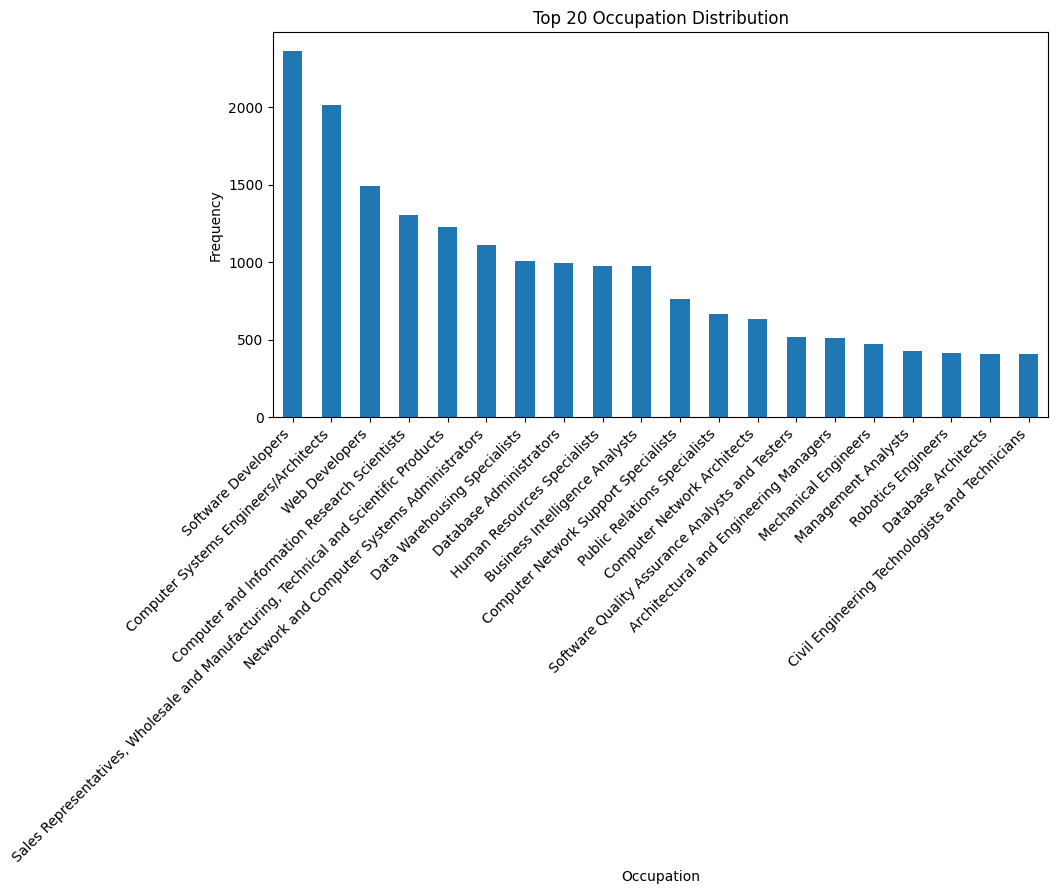

In [ ]:
# Top 10 most frequent occupations
top_classes = df_resumes_RecSys['Mapped_ONET_Title'].value_counts().head(20)

# Plot
plt.figure(figsize=(10,5))
top_classes.plot(kind='bar')
plt.title("Top 20 Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

count     241.000000
mean      104.082988
std       302.858908
min         1.000000
25%         1.000000
50%         2.000000
75%        14.000000
max      2366.000000
Name: count, dtype: float64


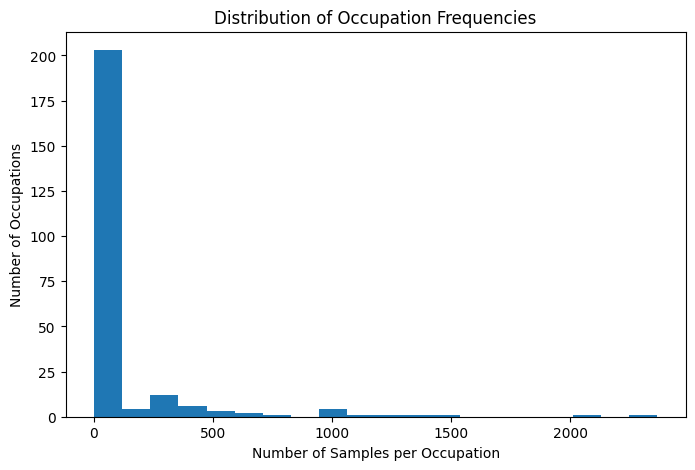

In [ ]:
class_counts = df_resumes_RecSys['Mapped_ONET_Title'].value_counts()

# Summary statistics of label distribution
print(class_counts.describe())

# Optional visualization
plt.figure(figsize=(8,5))
plt.hist(class_counts.values, bins=20)
plt.title("Distribution of Occupation Frequencies")
plt.xlabel("Number of Samples per Occupation")
plt.ylabel("Number of Occupations")
plt.show()

count    25084.000000
mean        35.661776
std         17.903873
min          1.000000
25%         23.000000
50%         34.000000
75%         44.000000
max        204.000000
Name: text_length, dtype: float64


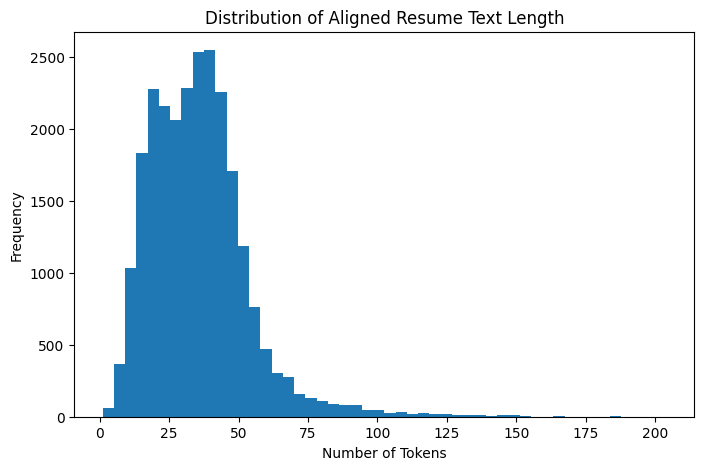

In [20]:
# Text length analysis
df_resumes_RecSys['text_length'] = df_resumes_RecSys['Aligned_Text'].apply(lambda x: len(str(x).split()))

print(df_resumes_RecSys['text_length'].describe())

# Plot distribution
plt.figure(figsize=(8,5))
plt.hist(df_resumes_RecSys['text_length'], bins=50)
plt.title("Distribution of Aligned Resume Text Length")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()